In [2]:
%load_ext autoreload
%autoreload 2

exactly the same as matlab--> output are the same

In [79]:
from fda_rof_funcs_v4 import TX, RX

params = {
    "Rt": 2.25,
    "k": 1.0,
    "para_N1": {"a": 2.0, "b": 4.0},
    "para_N2": {"a": 8, "b":2.6},
    "parabits_path": "parabits.mat",
}

tx_output = TX(params)
snr1, snr2, snr_total, ber = RX(tx_output, params)
print(snr1, snr2, snr_total, ber)

[0.00100937]
SNR of 1 symbols is 29.955113 dB
[4.88299132e-05]
SNR of 2 symbols is 43.112928 dB
[0.00076949]
SNR of t symbols is 31.134645 dB
BER = 3.332194e-01
29.955112654977448 43.112928406589994 31.134645321401667 0.33321940104166664


In [4]:
import numpy as np
import pandas as pd

from fda_rof_funcs_v2 import TX, RX

# 为了结果可复现
np.random.seed(42)

# ===== 通用固定参数 =====
a1_range = np.arange(3, 12, 1)                 # 3:1:11
b1_range = np.arange(0.8, 3.6 + 1e-9, 0.4)    # 0.8:0.4:3.6
a2_range = np.arange(2, 6 + 1e-9, 0.5)        # 2:0.5:6
b2_range = np.arange(0.6, 2.6 + 1e-9, 0.4)    # 0.6:0.4:2.6

# ===== 所有情景参数定义 =====
scenarios = [
    {"id": 1, "k": 1.0, "Rt": 2.25, "branch": "N1"},
    {"id": 2, "k": 1.0, "Rt": 2.25, "branch": "N2"},
    {"id": 3, "k": 1.4, "Rt": 2.25, "branch": "N1"},
    {"id": 4, "k": 1.4, "Rt": 2.25, "branch": "N2"},
    {"id": 5, "k": 1.4, "Rt": 2.75, "branch": "N1"},
    {"id": 6, "k": 1.4, "Rt": 2.75, "branch": "N2"},
    {"id": 7, "k": 1.4, "Rt": 3.25, "branch": "N1"},
    {"id": 8, "k": 1.4, "Rt": 3.25, "branch": "N2"},
    {"id": 9, "k": 1.8, "Rt": 3.25, "branch": "N1"},
    {"id": 10, "k": 1.8, "Rt": 3.25, "branch": "N2"},
]

# ===== parabits.mat 路径 =====
parabits_path = "parabits.mat"

# =========================================================
# 循环执行 10 个情景
# =========================================================
for sc in scenarios:
    print("\n==============================")
    print(f'>>> Running Scenario {sc["id"]}: k={sc["k"]:.2f}, Rt={sc["Rt"]:.2f}, branch={sc["branch"]}')
    print("==============================")

    results = []

    if sc["branch"] == "N1":
        for a1 in a1_range:
            for b1 in b1_range:
                params = {
                    "Rt": sc["Rt"],
                    "k": sc["k"],
                    "para_N1": {"a": float(a1), "b": float(b1)},
                    "para_N2": {"a": 3.0, "b": 1.0},
                    "parabits_path": parabits_path,
                }

                TX_output = TX(params)
                SNR_N1, SNR_N2, SNR_total, BER = RX(TX_output, params)

                results.append([
                    sc["Rt"], sc["k"], a1, b1,
                    SNR_N1, SNR_N2, SNR_total, BER
                ])

                print(
                    f"Rt={sc['Rt']:.2f}, k={sc['k']:.1f}, a1={a1:.1f}, b1={b1:.1f} -> "
                    f"SNR1={SNR_N1:.2f} dB, SNR2={SNR_N2:.2f} dB, "
                    f"SNR_total={SNR_total:.2f} dB, BER={BER:.2e}"
                )

        T = pd.DataFrame(
            results,
            columns=[
                "Rt", "k", "a1", "b1",
                "SNR_N1_dB", "SNR_N2_dB", "SNR_total_dB", "BER"
            ]
        )
        fname = f"Scenario_{sc['id']:02d}_N1_Rt{sc['Rt']:.2f}_k{sc['k']:.1f}.csv"
        T.to_csv(fname, index=False)
        print(f"Saved: {fname}")

    elif sc["branch"] == "N2":
        for a2 in a2_range:
            for b2 in b2_range:
                params = {
                    "Rt": sc["Rt"],
                    "k": sc["k"],
                    "para_N1": {"a": 4.0, "b": 1.2},
                    "para_N2": {"a": float(a2), "b": float(b2)},
                    "parabits_path": parabits_path,
                }

                TX_output = TX(params)
                SNR_N1, SNR_N2, SNR_total, BER = RX(TX_output, params)
                results.append([
                    sc["Rt"], sc["k"], a2, b2,
                    SNR_N1, SNR_N2, SNR_total, BER
                ])

                print(
                    f"Rt={sc['Rt']:.2f}, k={sc['k']:.1f}, a2={a2:.1f}, b2={b2:.1f} -> "
                    f"SNR1={SNR_N1:.2f} dB, SNR2={SNR_N2:.2f} dB, "
                    f"SNR_total={SNR_total:.2f} dB, BER={BER:.2e}"
                )

        T = pd.DataFrame(
            results,
            columns=[
                "Rt", "k", "a2", "b2",
                "SNR_N1_dB", "SNR_N2_dB", "SNR_total_dB", "BER"
            ]
        )
        fname = f"Scenario_{sc['id']:02d}_N2_Rt{sc['Rt']:.2f}_k{sc['k']:.1f}.csv"
        T.to_csv(fname, index=False)
        print(f"Saved: {fname}")

print("All 10 scenarios finished!")


>>> Running Scenario 1: k=1.00, Rt=2.25, branch=N1
[0.0002335]
SNR of 1 symbols is 36.316110 dB
[0.00070686]
SNR of 2 symbols is 31.503617 dB
[0.0003602]
SNR of t symbols is 34.432942 dB
BER = 3.332194e-01
Rt=2.25, k=1.0, a1=3.0, b1=0.8 -> SNR1=36.32 dB, SNR2=31.50 dB, SNR_total=34.43 dB, BER=3.33e-01
[0.0003312]
SNR of 1 symbols is 34.797685 dB
[0.00035868]
SNR of 2 symbols is 34.451395 dB
[0.00034494]
SNR of t symbols is 34.621093 dB
BER = 3.332194e-01
Rt=2.25, k=1.0, a1=3.0, b1=1.2 -> SNR1=34.80 dB, SNR2=34.45 dB, SNR_total=34.62 dB, BER=3.33e-01
[0.00086268]
SNR of 1 symbols is 30.637758 dB
[0.00037089]
SNR of 2 symbols is 34.305918 dB
[0.00074352]
SNR of t symbols is 31.283858 dB
BER = 3.332194e-01
Rt=2.25, k=1.0, a1=3.0, b1=1.6 -> SNR1=30.64 dB, SNR2=34.31 dB, SNR_total=31.28 dB, BER=3.33e-01
[0.00171271]
SNR of 1 symbols is 27.655724 dB
[0.00039379]
SNR of 2 symbols is 34.045609 dB
[0.00138235]
SNR of t symbols is 28.587806 dB
BER = 3.332194e-01
Rt=2.25, k=1.0, a1=3.0, b1=2.0 -

KeyboardInterrupt: 

NEW

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fda_rof_funcs_v4 import TX, RX


PARABITS_PATH = "parabits.mat"   # 改成你的实际路径


def make_params(Rt, k, a1, b1, a2, b2, parabits_path=PARABITS_PATH):
    return {
        "Rt": Rt,
        "k": float(k),
        "para_N1": {"a": float(a1), "b": float(b1)},
        "para_N2": {"a": float(a2), "b": float(b2)},
        "parabits_path": parabits_path,
    }


def run_once(params, seed=None):
    if seed is not None:
        
        np.random.seed(seed)

    tx_output = TX(params)
    snr1, snr2, snr_total, ber = RX(tx_output, params)

    return {
        "Rt": params["Rt"],
        "k": params["k"],
        "a1": params["para_N1"]["a"],
        "b1": params["para_N1"]["b"],
        "a2": params["para_N2"]["a"],
        "b2": params["para_N2"]["b"],
        "snr1": snr1,
        "snr2": snr2,
        "snr_total": snr_total,
        "ber": ber,
    }


def run_avg(params, n_repeats=3, base_seed=1000):
    rows = []
    for i in range(n_repeats):
        rows.append(run_once(params, seed=base_seed + i))
    df = pd.DataFrame(rows)
    mean_rec = df.mean(numeric_only=True).to_dict()

    mean_rec["Rt"] = params["Rt"]
    mean_rec["k"] = params["k"]
    mean_rec["a1"] = params["para_N1"]["a"]
    mean_rec["b1"] = params["para_N1"]["b"]
    mean_rec["a2"] = params["para_N2"]["a"]
    mean_rec["b2"] = params["para_N2"]["b"]

    return mean_rec


def scan_a1_b1_lines(
    Rt,
    k,
    a2,
    b2,
    a1_range,
    b1_range,
    snr_key="snr1",      # 可选: "snr1", "snr2", "snr_total"
    n_repeats=3,
    parabits_path=PARABITS_PATH,
):
    rows = []

    for b1 in b1_range:
        for a1 in a1_range:
            params = make_params(
                Rt=Rt, k=k,
                a1=a1, b1=b1,
                a2=a2, b2=b2,
                parabits_path=parabits_path
            )
            rec = run_avg(params, n_repeats=n_repeats)
            rows.append(rec)

    df = pd.DataFrame(rows)
    return df


def plot_a1_b1_lines(
    df,
    snr_key="snr1",
    title=None,
):
    plt.figure(figsize=(7, 5))

    b1_values = sorted(df["b1"].unique())
    for b1 in b1_values:
        df_sub = df[df["b1"] == b1].sort_values("a1")
        plt.plot(
            df_sub["a1"],
            df_sub[snr_key],
            marker="o",
            label=f"b1={b1}"
        )

    plt.xlabel("a1")
    plt.ylabel(snr_key)
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()
def scan_a2_b2_lines(
    Rt,
    k,
    a1,
    b1,
    a2_range,
    b2_range,
    snr_key="snr2",      # 可选: "snr1", "snr2", "snr_total"
    n_repeats=3,
    parabits_path=PARABITS_PATH,
):
    rows = []

    for b2 in b2_range:
        for a2 in a2_range:
            params = make_params(
                Rt=Rt, k=k,
                a1=a1, b1=b1,
                a2=a2, b2=b2,
                parabits_path=parabits_path
            )
            rec = run_avg(params, n_repeats=n_repeats)
            rows.append(rec)

    df = pd.DataFrame(rows)
    return df


def plot_a2_b2_lines(
    df,
    snr_key="snr2",
    title=None,
):
    plt.figure(figsize=(7, 5))

    b2_values = sorted(df["b2"].unique())
    for b2 in b2_values:
        df_sub = df[df["b2"] == b2].sort_values("a2")
        plt.plot(
            df_sub["a2"],
            df_sub[snr_key],
            marker="o",
            label=f"b2={b2}"
        )

    plt.xlabel("a2")
    plt.ylabel(snr_key)
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()
def scan_total_SNR_k_lines(
    Rt,
    a1,
    b1,
    a2,
    b2,
    k_range,
    n_repeats=2,
    parabbits_path=PARABITS_PATH,
):
    rows = []

    for k in k_range:
        params = make_params(
            Rt=Rt, k=k,
            a1=a1, b1=b1,
            a2=a2, b2=b2,

        )
        rec = run_avg(params, n_repeats=n_repeats)
        rows.append(rec)

    df = pd.DataFrame(rows)
    return df
def plot_total_SNR_k_lines(
    df,
    title=None,
):
    plt.figure(figsize=(7, 5))

    k_values = sorted(df["k"].unique())
    for k in k_values:
        df_sub = df[df["k"] == k].sort_values("Rt")
        plt.plot(
            df_sub["k"],
            df_sub["snr_total"],
            marker="o",
            label=f"k={k}"
        )

    plt.xlabel("Power factor k")
    plt.ylabel("Total SNR (dB)")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()
def plot_total_SNR_k_lines_by_Rt(df, title=None):
    import matplotlib.pyplot as plt
    df = df.copy()
    df['k'] = df['k'].astype(float)
    plt.figure(figsize=(7,5))

    for Rt in sorted(df['Rt'].unique()):
        df_sub = df[df['Rt'] == Rt].sort_values('k')
        if df_sub.shape[0] < 2:
            # 如果该 Rt 下只有一个点，仍然画出点（无连线）
            plt.plot(df_sub['k'], df_sub['snr_total'], marker='o', linestyle='', label=f'Rt={Rt}')
        else:
            plt.plot(df_sub['k'], df_sub['snr_total'], marker='o', linestyle='-', label=f'Rt={Rt}')

    plt.xlabel("Power factor k")
    plt.ylabel("Total SNR (dB)")
    if title:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def print_best_per_b2(df, snr_key="snr2"):
    b2_values = sorted(df["b2"].unique())
    best_rows = []

    for b2 in b2_values:
        df_sub = df[df["b2"] == b2]
        idx = df_sub[snr_key].idxmax()
        best_rows.append(df_sub.loc[idx])

    best_df = pd.DataFrame(best_rows).reset_index(drop=True)
    print(best_df[["a2", "b2", snr_key]])
    return best_df

In [50]:
# 你自己填范围
a1_range = np.round(np.arange(3.0, 13.0, 1), 2)
b1_range = np.round(np.arange(0.8, 3.6, 0.4), 2)

df_fig5_like = scan_a1_b1_lines(
    Rt=2.25,
    k=1.0,
    a2=3.0,
    b2=1.0,
    a1_range=a1_range,
    b1_range=b1_range,
    snr_key="snr1",   # 一般这个模块先画 snr1
    n_repeats=1
)

plot_a1_b1_lines(
    df_fig5_like,
    snr_key="snr1",
    title="Rt = 3.25, k = 1.8"
)

[1.52588065e-06]
SNR of 1 symbols is 58.164788 dB
[0.00034952]
SNR of 2 symbols is 34.563788 dB
[9.61373023e-05]
SNR of t symbols is 40.170663 dB


KeyboardInterrupt: 

[0.00058314]
SNR of 1 symbols is 32.339733 dB
[1.83107983e-05]
SNR of 2 symbols is 47.372848 dB
[0.00044418]
SNR of t symbols is 33.522493 dB
BER = 3.332194e-01
[0.00057398]
SNR of 1 symbols is 32.408558 dB
[7.62943819e-06]
SNR of 2 symbols is 51.175041 dB
[0.00043502]
SNR of t symbols is 33.613044 dB
BER = 3.332194e-01
[0.00058009]
SNR of 1 symbols is 32.362554 dB
[0.00035562]
SNR of 2 symbols is 34.488537 dB
[0.00052816]
SNR of t symbols is 32.770024 dB
BER = 3.332194e-01
[0.00057398]
SNR of 1 symbols is 32.408558 dB
[0.00026098]
SNR of 2 symbols is 35.832855 dB
[0.00049915]
SNR of t symbols is 33.015528 dB
BER = 3.332194e-01
[0.0005755]
SNR of 1 symbols is 32.397012 dB
[1.52588065e-06]
SNR of 2 symbols is 58.164788 dB
[0.00043349]
SNR of t symbols is 33.628321 dB
BER = 3.332194e-01
[0.00057245]
SNR of 1 symbols is 32.420136 dB
[0.00015718]
SNR of 2 symbols is 38.035232 dB
[0.00047166]
SNR of t symbols is 33.261630 dB
BER = 3.332194e-01
[0.00057856]
SNR of 1 symbols is 32.374010 dB
[

D:\PycharmProjects\FYP\Baseline\fda_rof_funcs_v4.py:624: RuntimeWarning: divide by zero encountered in scalar divide
  SNR_OFDM = 10 * np.log10((1 - N0_scalar) / N0_scalar)


BER = 3.332194e-01
[0.00077101]
SNR of 1 symbols is 31.126025 dB
[0.00083365]
SNR of 2 symbols is 30.786537 dB
[0.00079087]
SNR of t symbols is 31.015491 dB
BER = 3.332194e-01
[0.00074199]
SNR of 1 symbols is 31.292797 dB
[0.00052205]
SNR of 2 symbols is 32.820570 dB
[0.00069005]
SNR of t symbols is 31.608170 dB
BER = 3.332194e-01
[0.00076032]
SNR of 1 symbols is 31.186727 dB
[0.00035868]
SNR of 2 symbols is 34.451395 dB
[0.00066256]
SNR of t symbols is 31.784866 dB
BER = 3.332194e-01
[0.00074046]
SNR of 1 symbols is 31.301754 dB
[0.0002625]
SNR of 2 symbols is 35.807520 dB
[0.00062438]
SNR of t symbols is 32.042821 dB
BER = 3.332194e-01
[0.0007481]
SNR of 1 symbols is 31.257152 dB
[0.00019839]
SNR of 2 symbols is 37.023858 dB
[0.00061369]
SNR of t symbols is 32.117874 dB
BER = 3.332194e-01
[0.00074199]
SNR of 1 symbols is 31.292797 dB
[0.00015718]
SNR of 2 symbols is 38.035232 dB
[0.00059689]
SNR of t symbols is 32.238495 dB
BER = 3.332194e-01
[0.00074963]
SNR of 1 symbols is 31.24828

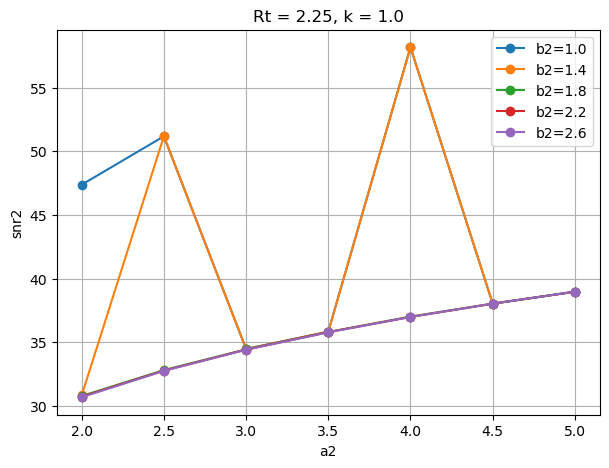

    a2   b2       snr2
0  4.0  1.0  58.164788
1  5.0  1.4        inf
2  5.0  1.8  38.973056
3  5.0  2.2  38.973056
4  5.0  2.6  38.973056


In [82]:
a2_range = np.round(np.arange(2.0, 5.1, 0.5), 2)
b2_range = np.round(np.arange(1.0, 2.7, 0.4), 2)

df_fig5_like_n2 = scan_a2_b2_lines(
    Rt=2.25,
    k=1.0,
    a1=2.0,
    b1=4.0,
    a2_range=a2_range,
    b2_range=b2_range,
    snr_key="snr2",
    n_repeats=1
)

plot_a2_b2_lines(
    df_fig5_like_n2,
    snr_key="snr2",
    title="Rt = 2.25, k = 1.0"
)

best_per_b2 = print_best_per_b2(df_fig5_like_n2, snr_key="snr2")

[0.00083976]
SNR of 1 symbols is 30.754790 dB
[0.0003541]
SNR of 2 symbols is 34.507228 dB
[0.0007206]
SNR of t symbols is 31.419902 dB
BER = 3.332194e-01
[0.00058009]
SNR of 1 symbols is 32.362554 dB
[0.00035562]
SNR of 2 symbols is 34.488537 dB
[0.00052816]
SNR of t symbols is 32.770024 dB
BER = 3.332194e-01
[0.00050831]
SNR of 1 symbols is 32.936494 dB
[0.00035715]
SNR of 2 symbols is 34.469926 dB
[0.00047472]
SNR of t symbols is 33.233587 dB
BER = 3.332194e-01
[0.0004793]
SNR of 1 symbols is 33.191860 dB
[0.0003602]
SNR of 2 symbols is 34.432942 dB
[0.00045334]
SNR of t symbols is 33.433789 dB
BER = 3.332194e-01
[0.00046403]
SNR of 1 symbols is 33.332537 dB
[1.37330516e-05]
SNR of 2 symbols is 48.622270 dB
[0.0003541]
SNR of t symbols is 34.507228 dB
BER = 3.332194e-01
[0.00045487]
SNR of 1 symbols is 33.419179 dB
[0.00036631]
SNR of 2 symbols is 34.359903 dB
[0.0004396]
SNR of t symbols is 33.567533 dB
BER = 3.332194e-01


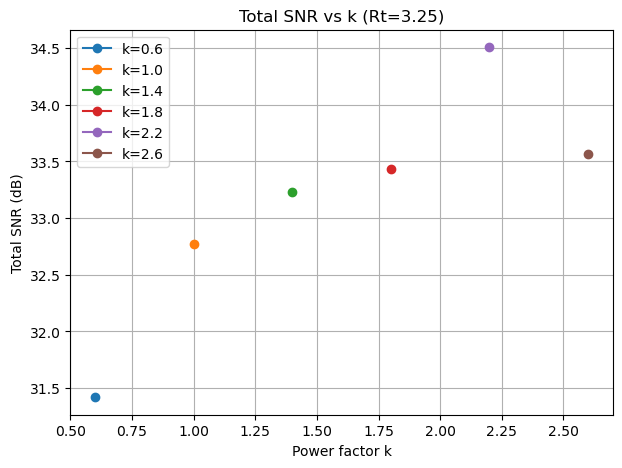

In [53]:
a1 = 2.0
b1 = 4.0
a2 = 3.0
b2 = 1.0
k_range = np.round(np.arange(0.6, 2.7, 0.4), 2)
df_total_SNR_k = scan_total_SNR_k_lines(
    Rt=2.25,
    a1=a1, b1=b1,
    a2=a2, b2=b2,
    k_range=k_range,
    n_repeats=1
)
plot_total_SNR_k_lines(
    df_total_SNR_k,
    title="Total SNR vs k (Rt=3.25)"
)